In [42]:
import pandas as pd

df = pd.read_csv(r"C:\Users\msdee\Desktop\python 6-8\internet_usage_dataset.csv")

In [43]:
df.shape
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 1000 non-null   int64  
 1   State                1000 non-null   object 
 2   Internet Users       1000 non-null   int64  
 3   Data Usage per User  1000 non-null   float64
 4   Network Type         1000 non-null   object 
 5   Cost per GB          1000 non-null   float64
 6   Average Speed        1000 non-null   float64
 7   Urban/Rural          1000 non-null   object 
 8   Device Type          1000 non-null   object 
 9   Age Group            1000 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 78.3+ KB


Year                   0
State                  0
Internet Users         0
Data Usage per User    0
Network Type           0
Cost per GB            0
Average Speed          0
Urban/Rural            0
Device Type            0
Age Group              0
dtype: int64

In [46]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
df.ffill(inplace=True)

# Convert types
df['Year'] = df['Year'].astype(int) 

# Outlier Handling
numeric_df = df.select_dtypes(include=['int64','float64'])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

In [12]:
df['Total_Data_Consumption'] = df['Internet Users'] * df['Data Usage per User']
df['High_Usage'] = df['Data Usage per User'] > df['Data Usage per User'].mean()
df['Cost_per_Speed'] = df['Cost per GB'] / df['Average Speed']

In [47]:
#Statistical Overview
df.describe()

#Class Distribution (Urban vs Rural)
df['Urban/Rural'].value_counts()

#Correlation
df.corr(numeric_only=True)

,Year,Internet Users,Data Usage per User,Cost per GB,Average Speed
Year,1.000000,0.034156,-0.014195,-0.004437,0.004993
Internet Users,0.034156,1.000000,-0.015857,0.039604,-0.021667
Data Usage per User,-0.014195,-0.015857,1.000000,0.026338,0.039583
Cost per GB,-0.004437,0.039604,0.026338,1.000000,-0.072986
Average Speed,0.004993,-0.021667,0.039583,-0.072986,1.000000


In [ ]:
8. ADVANCED QUESTIONS
Pandas / NumPy (8 Questions)

In [48]:
df.groupby('Year')['Internet Users'].sum().idxmax()

np.int64(2015)

In [50]:
df.groupby('Network Type')['Data Usage per User'].mean()

Network Type
3G    15.224498
4G    15.608685
5G    15.385959
Name: Data Usage per User, dtype: float64

In [24]:
df.groupby('State')['Internet Users'].sum().nlargest(5)

State
Maharashtra    11571
Telangana      11505
UP             11140
Tamil Nadu     11031
Karnataka      11019
Name: Internet Users, dtype: int64

In [25]:
df.groupby('Urban/Rural')['Data Usage per User'].mean()

Urban/Rural
Rural    15.252619
Urban    15.561190
Name: Data Usage per User, dtype: float64

In [26]:
df[['Average Speed','Data Usage per User']].corr()

,Average Speed,Data Usage per User
Average Speed,1.000000,0.039583
Data Usage per User,0.039583,1.000000


In [29]:
df.groupby('Year')['Data Usage per User'].mean()

Year
2015    16.242182
2016    14.893671
2017    14.734660
2018    16.902024
2019    13.582745
2020    15.990690
2021    15.783256
2022    16.542111
2023    15.219886
2024    14.908600
2025    14.816901
Name: Data Usage per User, dtype: float64

In [30]:
df.groupby('Network Type')['Cost per GB'].mean()

Network Type
3G    8.492340
4G    8.461774
5G    8.196919
Name: Cost per GB, dtype: float64

In [32]:
df['Total_Data_Consumption'].sum()

np.float64(1194989.81)

In [ ]:
B) Visualization (7 Questions)

<Axes: xlabel='Network Type', ylabel='count'>

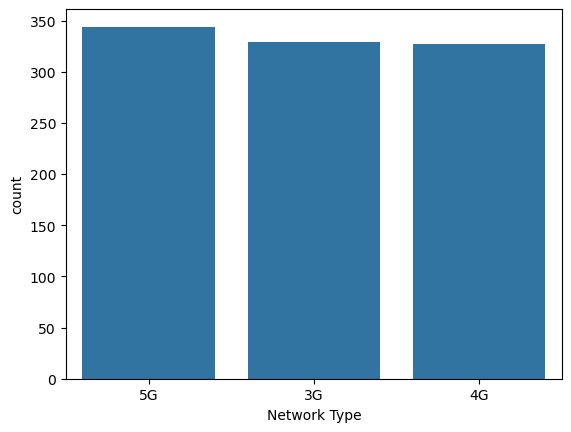

In [33]:
sns.countplot(x='Network Type', data=df)

<Axes: xlabel='Data Usage per User', ylabel='Count'>

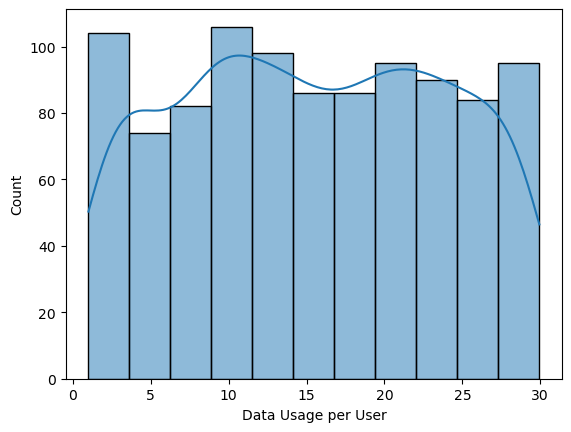

In [35]:
sns.histplot(df['Data Usage per User'], kde=True)

<Axes: xlabel='Average Speed', ylabel='Data Usage per User'>

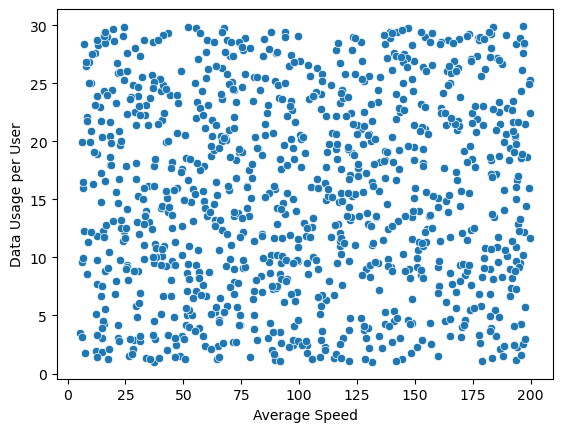

In [36]:
sns.scatterplot(x='Average Speed', y='Data Usage per User', data=df)

<Axes: xlabel='Urban/Rural', ylabel='Data Usage per User'>

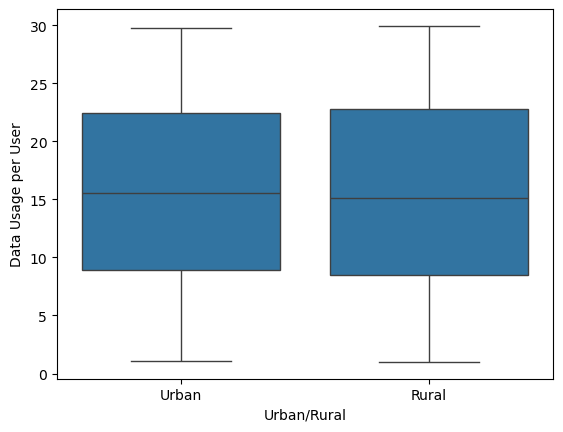

In [37]:
sns.boxplot(x='Urban/Rural', y='Data Usage per User', data=df)

<Axes: ylabel='count'>

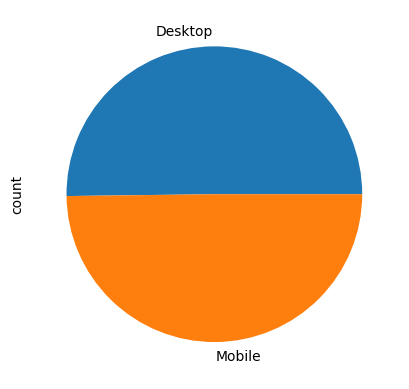

In [38]:
df['Device Type'].value_counts().plot.pie()

<Axes: xlabel='Year', ylabel='Data Usage per User'>

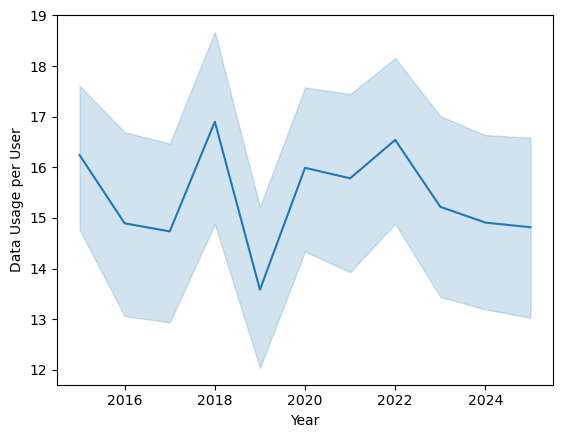

In [39]:
sns.lineplot(x='Year', y='Data Usage per User', data=df)

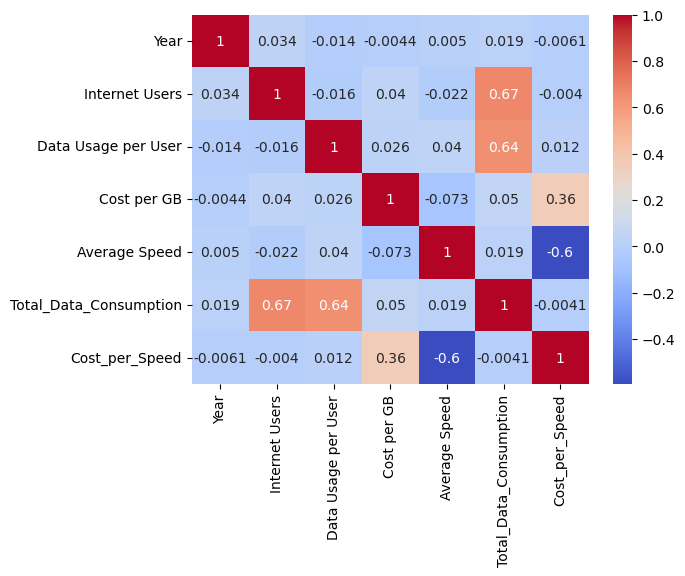

In [41]:
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()